In [1]:
import os, sys
import polars as pl

project_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')) 
sys.path.append(project_path)

sys.path.append(project_path)

from src.utils.experiments_exploration_utils import process_experiment_2_results, plot_experiment_2_results
from config.config_experiment_2 import (
    PROP_ERRORS_THRESHOLD,
    N_REALIZATIONS,
    CONFIG_EXPERIMENT
)

DATA_IDS = list(CONFIG_EXPERIMENT.keys())

In [2]:
df_results, df_avg_results = {}, {}

for data_id in DATA_IDS:

    print('-'*50)
    print(data_id.upper())
    print('-'*50)

    try:

        results_dir = os.path.join(project_path, 'results', 'experiment_2', data_id)
        filename = f'results_exp_2_{data_id}.pkl'
        results_path = os.path.join(results_dir, filename)

        df, df_avg = process_experiment_2_results(
            results_path=results_path,
            prop_errors_threshold=PROP_ERRORS_THRESHOLD
        )
         
        df_results[data_id] = df.clone()
        df_avg_results[data_id] = df_avg.clone()
        
        with pl.Config(tbl_rows=-1):
             display(df_avg)

    except Exception as e:
        print(e)

--------------------------------------------------
SIMULATION_BASE
--------------------------------------------------
✅ Archivo cargado correctamente. Tipo de objeto: <class 'dict'>
📊 Número de realizaciones (seeds) capturadas: 100


sample_size_pct,mean_acc,std_acc,mean_ari,std_ari,mean_time,std_time,prop_status_error
f64,f64,f64,f64,f64,f64,f64,f64
0.5,0.84219,0.108263,0.639097,0.195676,2.164141,1.301324,0.0
10.0,0.856118,0.100897,0.669149,0.186037,2.198594,1.423855,0.0
20.0,0.854641,0.103858,0.666426,0.190389,2.347051,1.422338,0.0
30.0,0.860228,0.099656,0.674653,0.187582,2.942298,1.839162,0.0
40.0,0.856394,0.1018,0.668702,0.189395,3.984093,2.389101,0.0
50.0,0.854353,0.105361,0.667908,0.191629,5.092504,3.026788,0.0


--------------------------------------------------
DUBAI_HOUSES
--------------------------------------------------
✅ Archivo cargado correctamente. Tipo de objeto: <class 'dict'>
📊 Número de realizaciones (seeds) capturadas: 100


sample_size_pct,mean_acc,std_acc,mean_ari,std_ari,mean_time,std_time,prop_status_error
f64,f64,f64,f64,f64,f64,f64,f64
5.0,0.802566,0.078748,0.467596,0.129889,0.72861,0.15194,0.0
10.0,0.825027,0.001417,0.506913,0.004374,0.725183,0.17712,0.0
20.0,0.824578,0.001273,0.505832,0.003911,0.706494,0.165676,0.0
30.0,0.824435,0.001323,0.505375,0.004075,0.680417,0.149337,0.0
40.0,0.824137,0.001199,0.504454,0.003705,0.682998,0.138063,0.0
50.0,0.823854,0.000959,0.50347,0.003158,0.712496,0.138729,0.0
60.0,0.823744,0.000981,0.50327,0.003227,0.742827,0.134588,0.0
70.0,0.823582,0.000927,0.502821,0.00309,0.78246,0.142338,0.0
80.0,0.82332,0.000812,0.501982,0.002596,0.86864,0.181069,0.0


--------------------------------------------------
HEART_DISEASE
--------------------------------------------------
✅ Archivo cargado correctamente. Tipo de objeto: <class 'dict'>
📊 Número de realizaciones (seeds) capturadas: 100


sample_size_pct,mean_acc,std_acc,mean_ari,std_ari,mean_time,std_time,prop_status_error
f64,f64,f64,f64,f64,f64,f64,f64
10.0,0.696364,0.072167,0.171876,0.114635,0.938533,0.286826,0.0
20.0,0.719057,0.072026,0.209673,0.115928,0.916848,0.284016,0.0
30.0,0.736094,0.061147,0.235058,0.107692,0.923353,0.281004,0.0
40.0,0.745724,0.053673,0.250299,0.100028,0.922712,0.27251,0.0
50.0,0.75,0.052523,0.258329,0.099897,0.938649,0.270923,0.0
60.0,0.748249,0.052813,0.254944,0.100837,0.947445,0.264834,0.0
70.0,0.747946,0.053144,0.25447,0.102436,0.892089,0.253262,0.0
80.0,0.745219,0.054069,0.249459,0.104309,0.880022,0.252586,0.0
90.0,0.735859,0.053932,0.231306,0.104198,0.867023,0.264467,0.0


--------------------------------------------------
KC_HOUSES
--------------------------------------------------
✅ Archivo cargado correctamente. Tipo de objeto: <class 'dict'>
📊 Número de realizaciones (seeds) capturadas: 100


sample_size_pct,mean_acc,std_acc,mean_ari,std_ari,mean_time,std_time,prop_status_error
f64,f64,f64,f64,f64,f64,f64,f64
0.5,0.433807,0.04448,0.038011,0.024665,12.438493,8.833523,0.0
1.0,0.442297,0.04138,0.041781,0.024057,12.158274,8.640257,0.0
5.0,0.451639,0.028509,0.048234,0.015617,11.663637,8.262504,0.0
10.0,0.45199,0.029728,0.050013,0.016234,12.404026,8.412836,0.0
20.0,0.450162,0.026966,0.048909,0.014228,17.273978,10.486169,0.0
30.0,0.442143,0.022446,0.044059,0.011852,25.947253,14.986424,0.0


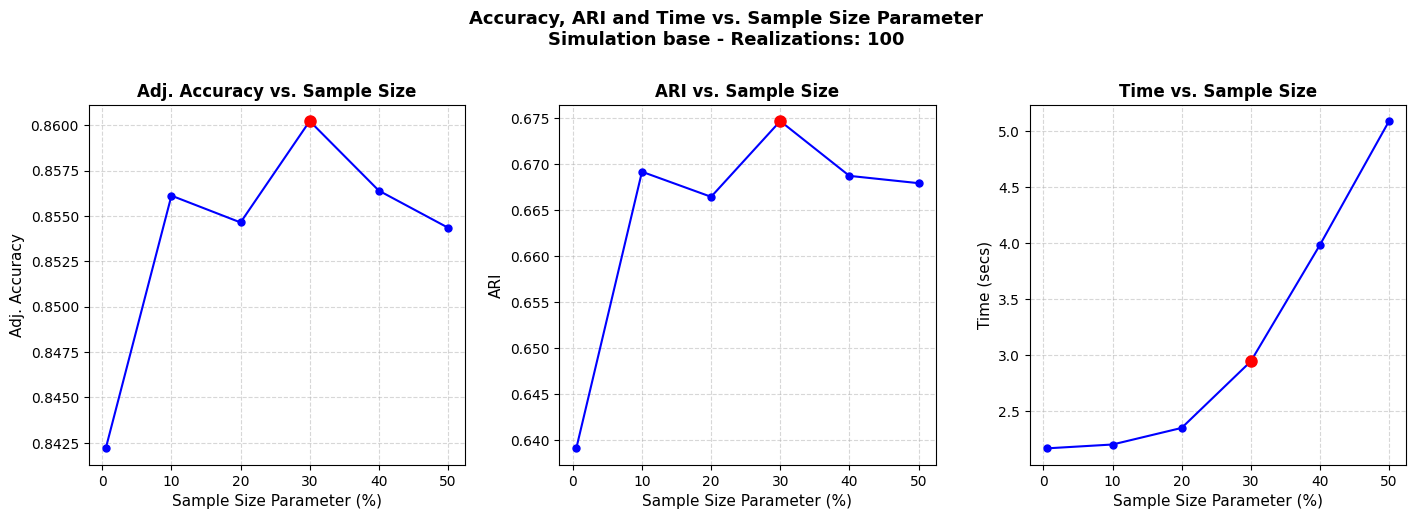

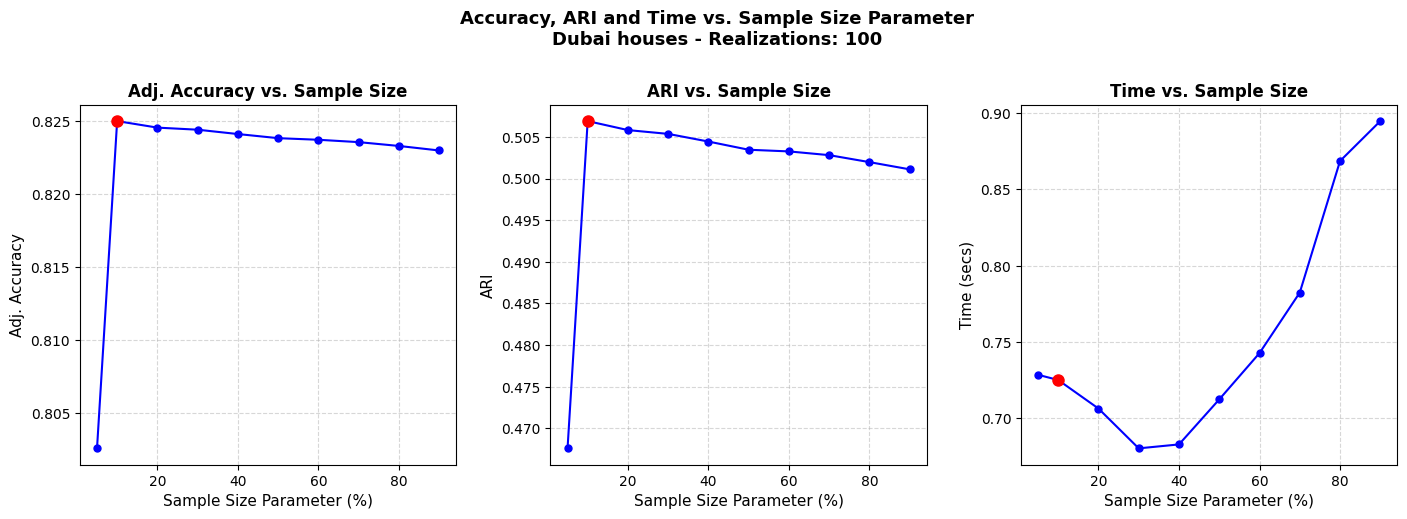

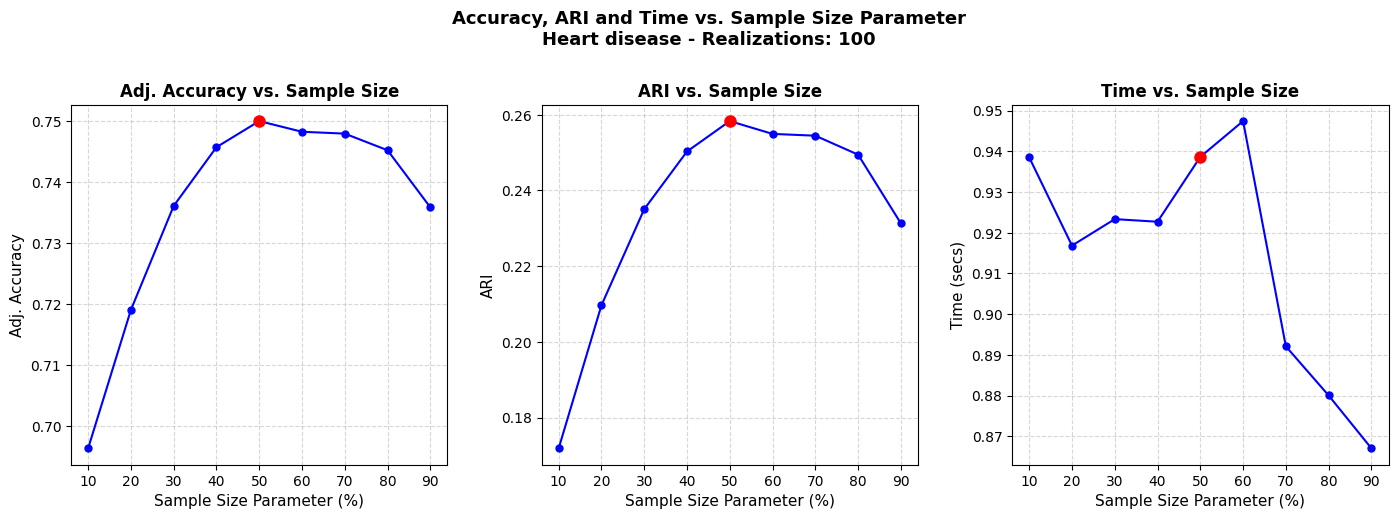

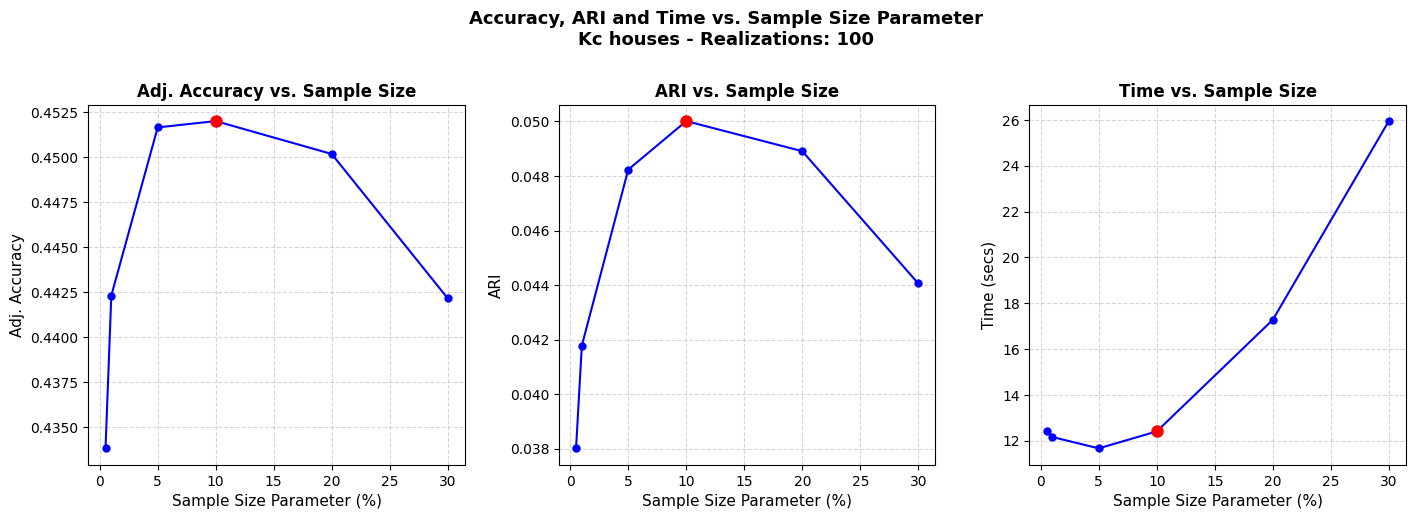

In [3]:
for data_id in DATA_IDS:

    error_style = None
    plot_filename = f'plot_results_exp_2_{data_id}.png'
    save_path = os.path.join(results_dir, plot_filename)

    plot_experiment_2_results(
        df=df_results[data_id], 
        df_avg=df_avg_results[data_id],
        data_name=data_id, 
        num_realizations=N_REALIZATIONS,
        error_style=error_style,
        #ylim_acc=ylim_acc,
        #ylim_ari=ylim_ari,
        #ylim_time=ylim_time,
        #save_path=save_path
    )    

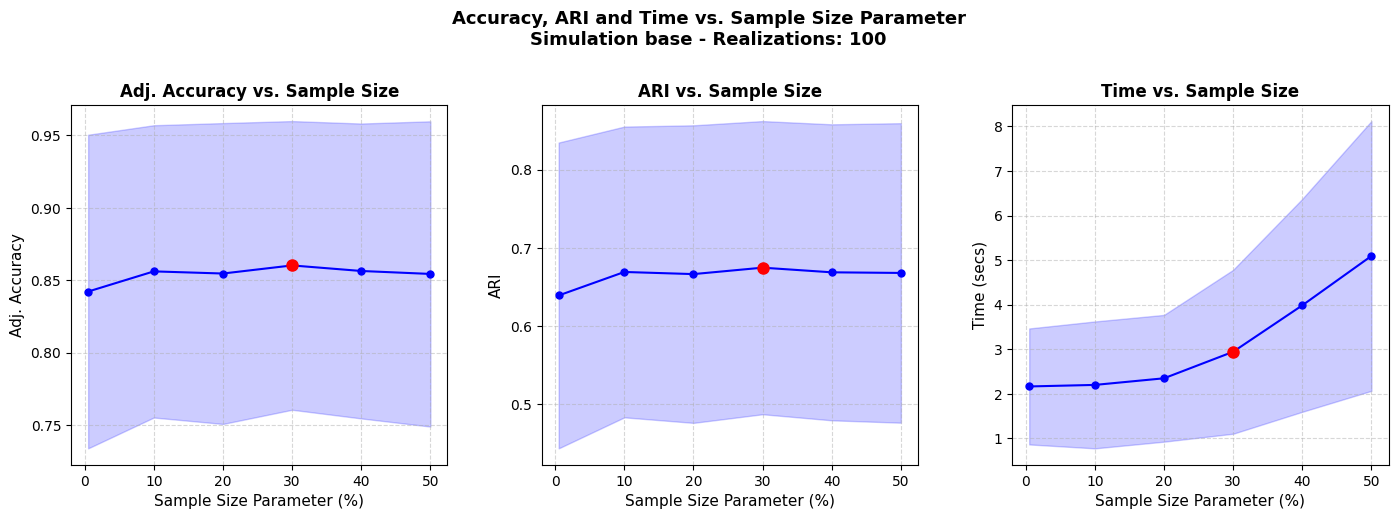

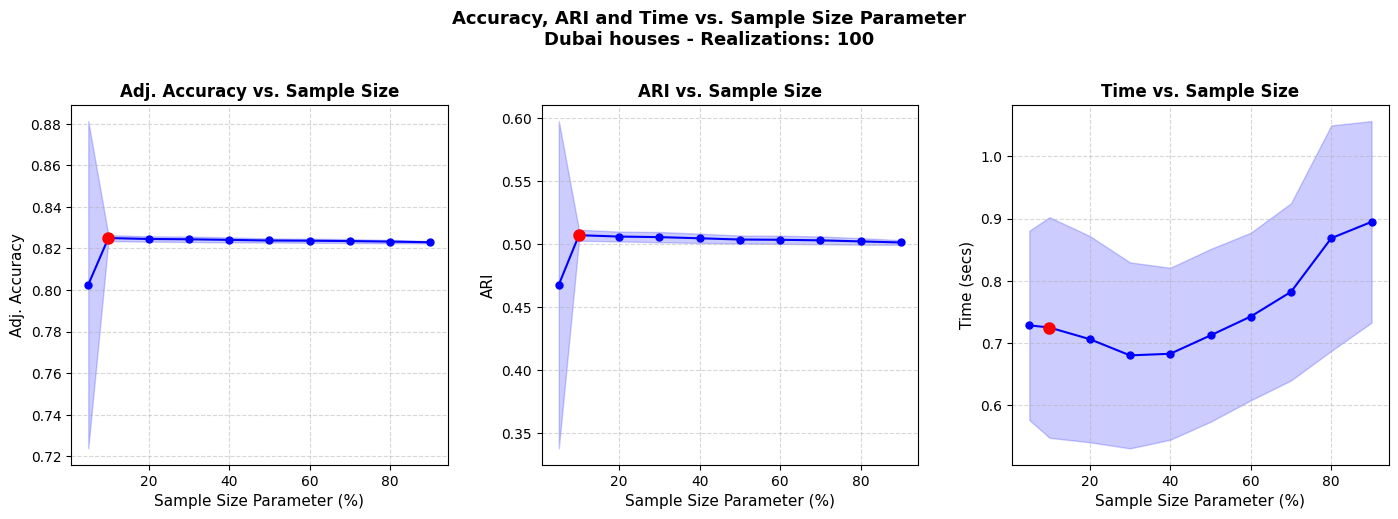

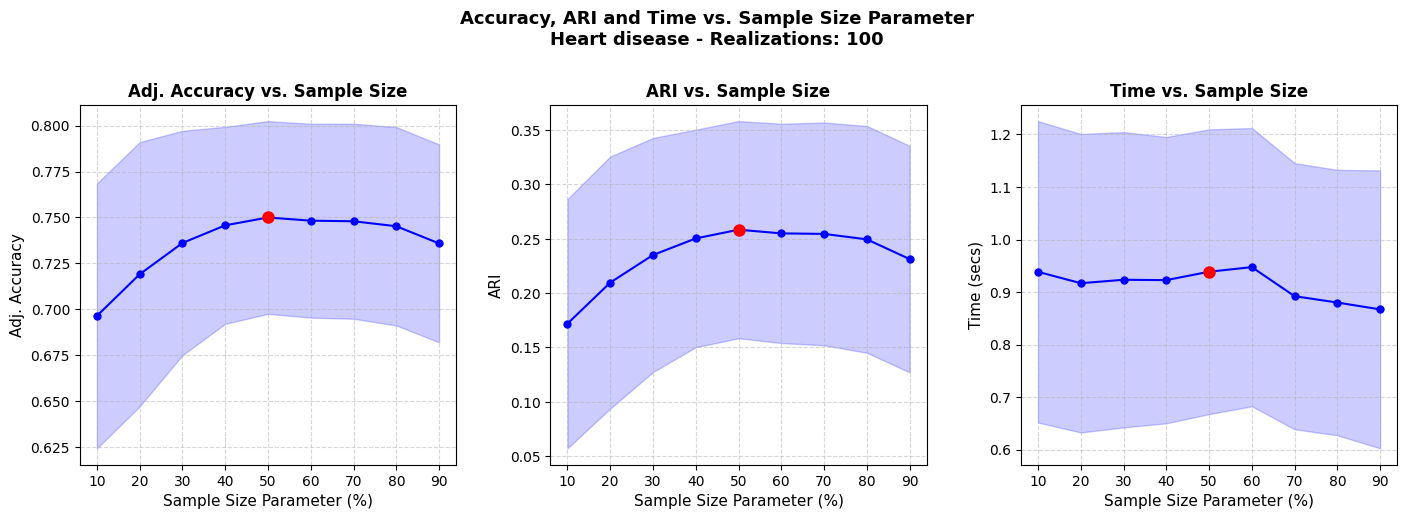

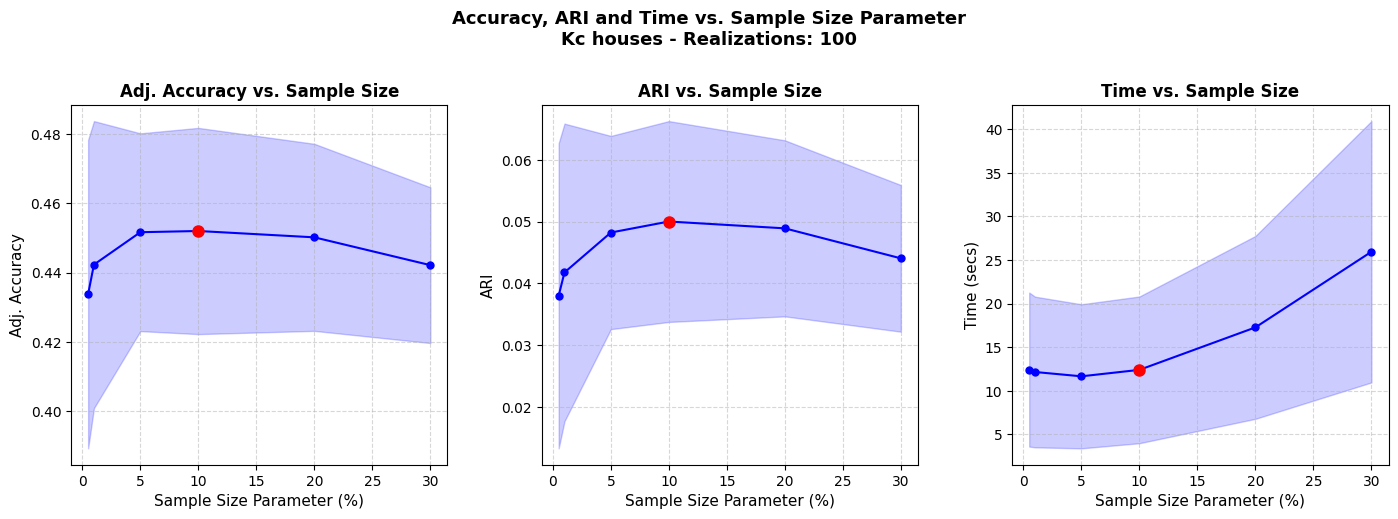

In [4]:
for data_id in DATA_IDS:

    error_style = 'fill'
    plot_filename = f'plot_results_exp_2_{data_id}_error_style_{error_style}.png'
    save_path = os.path.join(results_dir, plot_filename)

    plot_experiment_2_results(
        df=df_results[data_id], 
        df_avg=df_avg_results[data_id],
        data_name=data_id, 
        num_realizations=N_REALIZATIONS,
        error_style=error_style,
        #ylim_acc=ylim_acc,
        #ylim_ari=ylim_ari,
        #ylim_time=ylim_time,
        #save_path=save_path
    )    